In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files
uploaded = files.upload()

Saving Dataset .csv to Dataset .csv


In [2]:
df = pd.read_csv('Dataset .csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

found missing values in Cuisines column , which are very tiny i.e, 9 , since 9 is very little , the best handeling method is dropping them .. so doing it

In [3]:
df.dropna(subset=['Cuisines'], inplace=True)

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


notced "switch to order menu " column which is almost same going for a check

In [5]:
print(df['Switch to order menu'].value_counts())

Switch to order menu
No    9542
Name: count, dtype: int64


switch to order menu column has same value "No" from top to bottom,  so there is no need of having this , so  removing this

In [6]:
# Remove the constant column
df.drop(columns=['Switch to order menu'], inplace=True)

In [7]:
df['Has Table booking'] = np.where(df['Has Table booking'] == 'Yes', 1, 0)
df['Has Online delivery'] = np.where(df['Has Online delivery'] == 'Yes', 1, 0)
df['Is delivering now'] = np.where(df['Is delivering now'] == 'Yes', 1, 0)

print("Converted 'Has Table booking' unique values:")
print(df['Has Table booking'].value_counts())
print("\nConverted 'Has Online delivery' unique values:")
print(df['Has Online delivery'].value_counts())
print("\nConverted 'Is delivering now' unique values:")
print(df['Is delivering now'].value_counts())

Converted 'Has Table booking' unique values:
Has Table booking
0    8384
1    1158
Name: count, dtype: int64

Converted 'Has Online delivery' unique values:
Has Online delivery
0    7091
1    2451
Name: count, dtype: int64

Converted 'Is delivering now' unique values:
Is delivering now
0    9508
1      34
Name: count, dtype: int64


In [8]:
print(df['Aggregate rating'].describe())

count    9542.000000
mean        2.665238
std         1.516588
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


noticed mean(2.66) and  median (3.2) ,mean is lower than median . min is 0.0- 1st quarter 25% is 2.5 this means ,data sits between these

the class imbalance is between rated vs unrated ,
lets look into it

In [9]:
# Create a categorical version to see the imbalance clearly
rating_counts = df['Aggregate rating'].value_counts().sort_index()

# Specifically check the 0.0 count
zeros = (df['Aggregate rating'] == 0).sum()
print(f"Number of 0.0 ratings: {zeros}")
print(f"Percentage of 0.0 ratings: {round((zeros/len(df))*100, 2)}%")

Number of 0.0 ratings: 2148
Percentage of 0.0 ratings: 22.51%


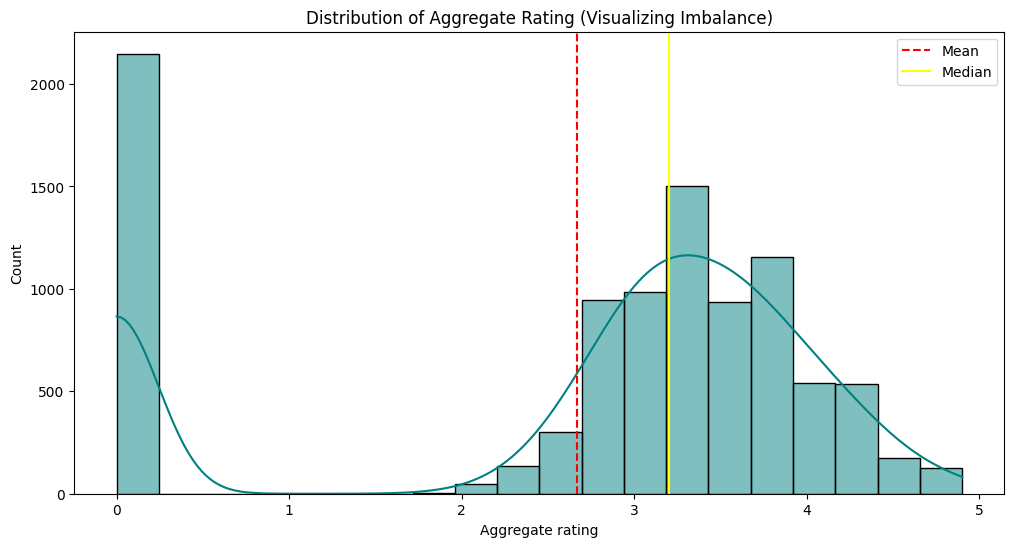

In [10]:
#visualising
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='teal')
plt.axvline(df['Aggregate rating'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Aggregate rating'].median(), color='yellow', linestyle='-', label='Median')
plt.title('Distribution of Aggregate Rating (Visualizing Imbalance)')
plt.legend()
plt.show()

In [11]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
count,9.542000e+03,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000
mean,9.043301e+06,18.179208,64.274997,25.848532,1200.326137,0.121358,0.256864,0.003563,1.804968,2.665238,156.772060
std,8.791967e+06,56.451600,41.197602,11.010094,16128.743876,0.326560,0.436927,0.059589,0.905563,1.516588,430.203324
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3.019312e+05,1.000000,77.081565,28.478658,250.000000,0.000000,0.000000,0.000000,1.000000,2.500000,5.000000
50%,6.002726e+06,1.000000,77.192031,28.570444,400.000000,0.000000,0.000000,0.000000,2.000000,3.200000,31.000000
75%,1.835260e+07,1.000000,77.282043,28.642711,700.000000,0.000000,1.000000,0.000000,2.000000,3.700000,130.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,1.000000,1.000000,1.000000,4.000000,4.900000,10934.000000


In [12]:
# Step 2: Get median separately (describe() skips it)
numerical_cols = ['Average Cost for two', 'Price range',
                  'Aggregate rating', 'Votes']

print("=== MEDIAN ===")
print(df[numerical_cols].median())

print("\n=== MEAN ===")
print(df[numerical_cols].mean())

print("\n=== STD DEVIATION ===")
print(df[numerical_cols].std())

print("\n=== SKEWNESS (are values lopsided?) ===")
print(df[numerical_cols].skew())

=== MEDIAN ===
Average Cost for two    400.0
Price range               2.0
Aggregate rating          3.2
Votes                    31.0
dtype: float64

=== MEAN ===
Average Cost for two    1200.326137
Price range                1.804968
Aggregate rating           2.665238
Votes                    156.772060
dtype: float64

=== STD DEVIATION ===
Average Cost for two    16128.743876
Price range                 0.905563
Aggregate rating            1.516588
Votes                     430.203324
dtype: float64

=== SKEWNESS (are values lopsided?) ===
Average Cost for two    35.461264
Price range              0.889879
Aggregate rating        -0.953052
Votes                    8.813270
dtype: float64


"Average Cost for Two is extremely right-skewed (skewness=35.46), indicating the presence of high-cost outlier restaurants, likely from high-income countries. Median (400) is a more reliable central tendency measure than mean (1200) for this column."

In [13]:
print(df[df['Aggregate rating'] == 0]['Rating text'].value_counts())

Rating text
Not rated    2148
Name: count, dtype: int64


In [14]:
print(f"Total restaurants: {len(df)}")
print(f"Not rated restaurants: {df[df['Aggregate rating'] == 0].shape[0]}")
print(f"Percentage unrated: {df[df['Aggregate rating'] == 0].shape[0]/len(df)*100:.2f}%")

Total restaurants: 9542
Not rated restaurants: 2148
Percentage unrated: 22.51%


In [15]:
# Separate rated vs unrated
df_rated = df[df['Aggregate rating'] > 0]
df_unrated = df[df['Aggregate rating'] == 0]

print(f"Rated restaurants: {len(df_rated)}")
print(f"Unrated restaurants: {len(df_unrated)}")

Rated restaurants: 7394
Unrated restaurants: 2148


2,148 restaurants (22.5%) have an Aggregate Rating of 0.0, corresponding to 'Not Rated' status. These are not poor-quality restaurants but simply unreviewed ones. For all rating-based analysis, a filtered dataset (df_rated, n=7,394) will be used to avoid statistical distortion.



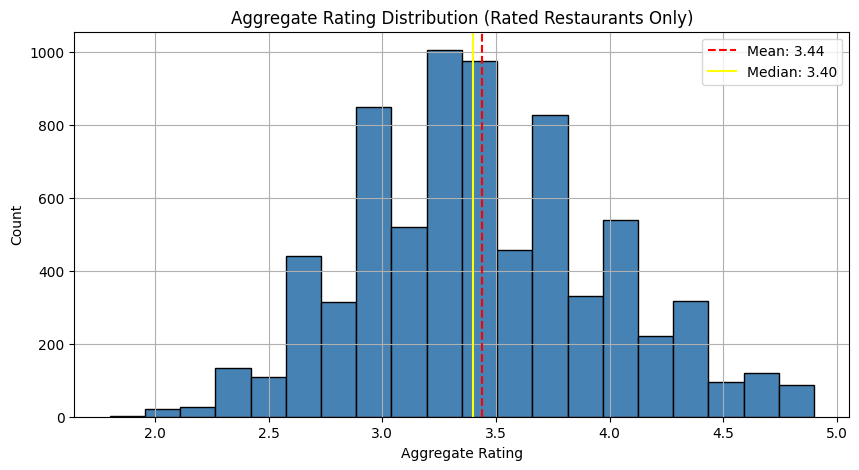

In [16]:
plt.figure(figsize=(10, 5))
df_rated['Aggregate rating'].hist(bins=20, color='steelblue', edgecolor='black')
plt.axvline(df_rated['Aggregate rating'].mean(), color='red', linestyle='--', label=f"Mean: {df_rated['Aggregate rating'].mean():.2f}")
plt.axvline(df_rated['Aggregate rating'].median(), color='yellow', linestyle='-', label=f"Median: {df_rated['Aggregate rating'].median():.2f}")
plt.title('Aggregate Rating Distribution (Rated Restaurants Only)')
plt.xlabel('Aggregate Rating')
plt.ylabel('Count')
plt.legend()
plt.show()

After removing unrated restaurants, the Aggregate Rating distribution becomes approximately normal (Mean=3.44, Median=3.40). Most restaurants are rated between 3.0–4.0, suggesting a generally average-to-good quality pool. Truly excellent (4.5+) and poor (<2.5) restaurants are both rare in this dataset.

=== Country Code Distribution ===
Country Code
1      8652
216     425
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


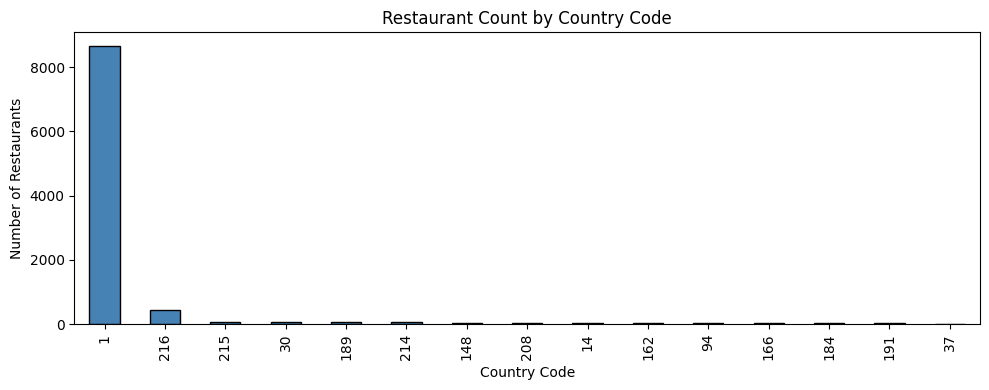

In [17]:
#countrycode column
print("=== Country Code Distribution ===")
print(df['Country Code'].value_counts())

df['Country Code'].value_counts().plot(
    kind='bar', figsize=(10, 4), color='steelblue', edgecolor='black'
)
plt.title('Restaurant Count by Country Code')
plt.xlabel('Country Code')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

The dataset is heavily dominated by Country Code 1 (India) which accounts for ~90% of all restaurants. This introduces a significant geographic bias — any global conclusions drawn from this dataset will inherently reflect Indian restaurant trends more than any other country.

=== Top 15 Cities ===
City
New Delhi          5473
Gurgaon            1118
Noida              1080
Faridabad           251
Ghaziabad            25
Bhubaneshwar         21
Ahmedabad            21
Lucknow              21
Guwahati             21
Amritsar             21
S��o Paulo           20
Bras�_lia            20
Doha                 20
Cape Town            20
Wellington City      20
Name: count, dtype: int64


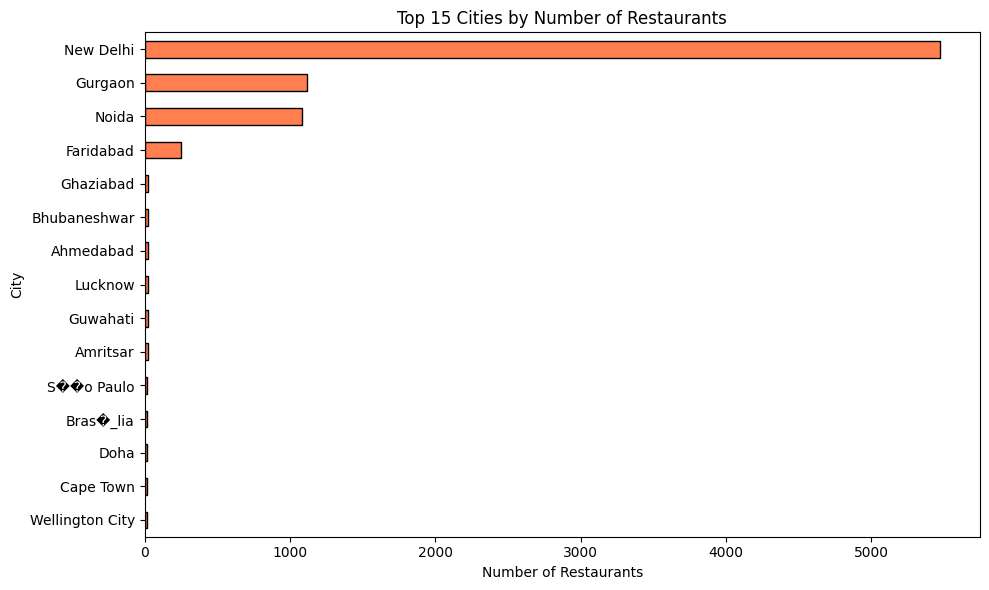

In [18]:
#top 15 cities
print("=== Top 15 Cities ===")
print(df['City'].value_counts().head(15))

df['City'].value_counts().head(15).plot(
    kind='barh', figsize=(10, 6), color='coral', edgecolor='black'
)
plt.title('Top 15 Cities by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Top 15 Individual Cuisines ===
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Name: count, dtype: int64


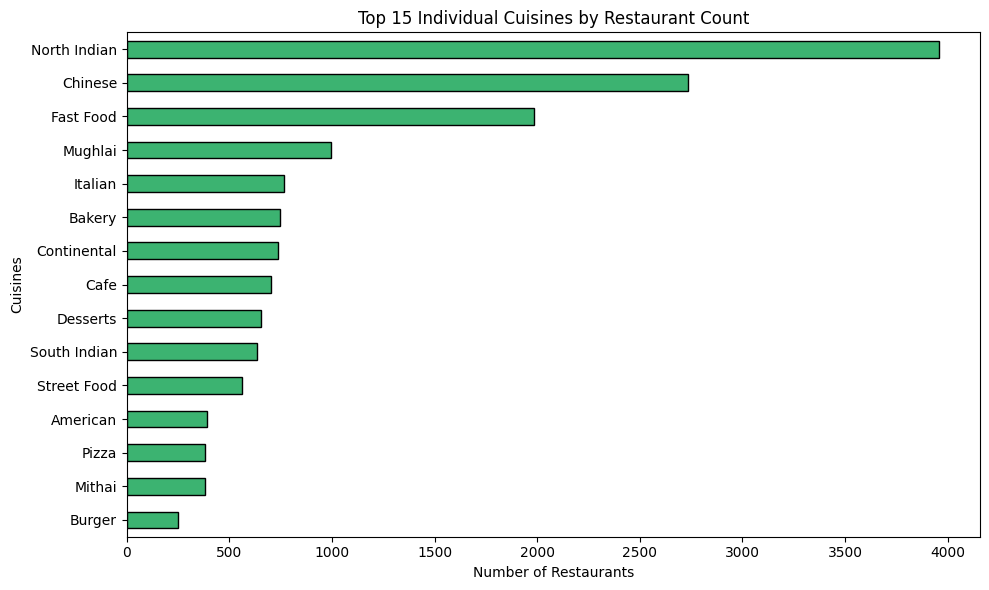

In [19]:
#top 15 cuisisnes individually
from collections import Counter

all_cuisines = df['Cuisines'].str.split(', ').explode()

print("=== Top 15 Individual Cuisines ===")
print(all_cuisines.value_counts().head(15))

all_cuisines.value_counts().head(15).plot(
    kind='barh', figsize=(10, 6), color='mediumseagreen', edgecolor='black'
)
plt.title('Top 15 Individual Cuisines by Restaurant Count')
plt.xlabel('Number of Restaurants')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

New Delhi dominates with ~5,500 restaurants, followed by Gurgaon and Noida — all part of the Delhi NCR metropolitan region. Together the top 4 cities (all NCR) account for the majority of Indian restaurants. Some city names show encoding artifacts (São Paulo, Brasília) indicating residual data quality issues.

North Indian cuisine dominates with ~4,000 restaurants, reflecting the dataset's heavy concentration in Delhi NCR. Chinese (likely Indo-Chinese fusion) ranks second. The top 15 cuisines are a mix of traditional Indian (North Indian, Mughlai, South Indian, Mithai), global fast food (Fast Food, Burger, Pizza), and urban dining formats (Cafe, Bakery, Continental).

#Task 3 : Geospetical analyis


In [20]:
!pip install folium

import folium
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from folium.plugins import HeatMap

visualising restaurent locations on map

In [21]:
# Start with a sample — plotting all 9542 will be slow
df_sample = df.sample(500, random_state=42)

# Create base map centered at mean lat/long
restaurant_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=4
)

# Add each restaurant as a dot
for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['Restaurant Name']} | Rating: {row['Aggregate rating']}"
    ).add_to(restaurant_map)

# Save and display in Colab
restaurant_map.save('restaurant_map.html')

from IPython.display import display, HTML
display(HTML(open('restaurant_map.html').read()))

Heatmap of restaurent density

In [22]:
# Use all data for heatmap
heat_data = df[['Latitude', 'Longitude']].dropna().values.tolist()

heat_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=4
)

HeatMap(heat_data, radius=8, blur=10).add_to(heat_map)

heat_map.save('heatmap.html')
display(HTML(open('heatmap.html').read()))

Distribution across countries and cities

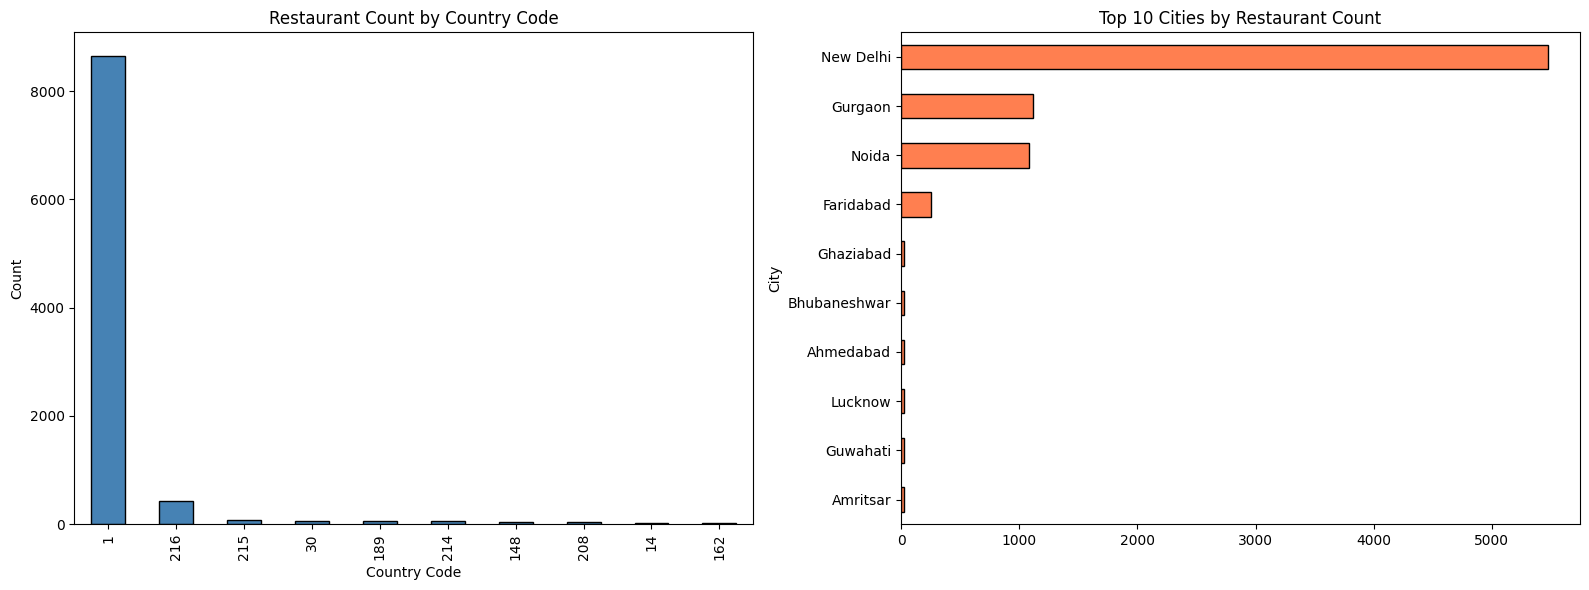

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Country distribution
df['Country Code'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Restaurant Count by Country Code')
axes[0].set_xlabel('Country Code')
axes[0].set_ylabel('Count')

# City distribution
df['City'].value_counts().head(10).plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Top 10 Cities by Restaurant Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

checking geograpy  , Average rating by country

=== Average Rating by Country Code ===
Country Code
162    4.468182
208    4.300000
94     4.295238
148    4.262500
214    4.233333
189    4.210000
215    4.139241
30     4.105455
166    4.060000
216    4.035782
191    3.870000
14     3.658333
37     3.575000
184    3.575000
1      3.352034
Name: Aggregate rating, dtype: float64


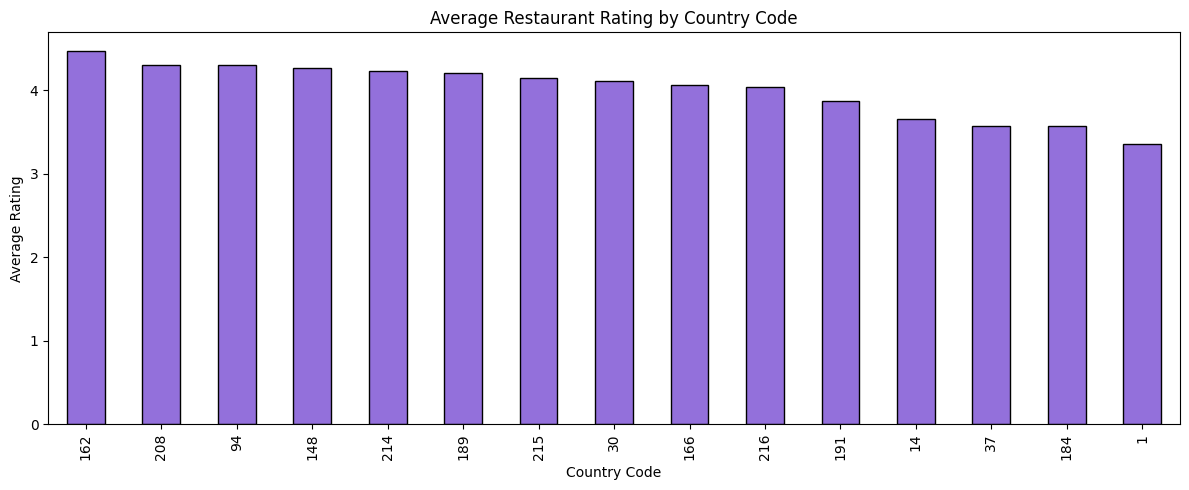

In [24]:
country_rating = df[df['Aggregate rating'] > 0].groupby('Country Code')['Aggregate rating'].mean().sort_values(ascending=False)

print("=== Average Rating by Country Code ===")
print(country_rating)

country_rating.plot(kind='bar', figsize=(12, 5), color='mediumpurple', edgecolor='black')
plt.title('Average Restaurant Rating by Country Code')
plt.xlabel('Country Code')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

average rating by city

=== Top 15 Cities by Average Rating ===
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Lincoln             4.500000
Tagaytay City       4.500000
Secunderabad        4.500000
Rio de Janeiro      4.489474
Orlando             4.478947
Tampa Bay           4.410000
Palm Cove           4.400000
Name: Aggregate rating, dtype: float64


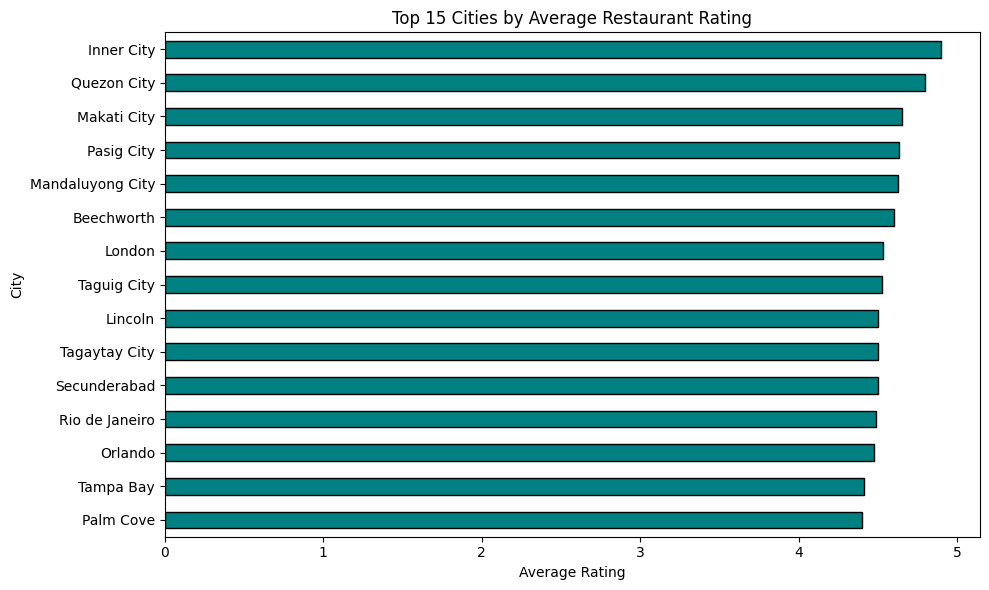

In [25]:
city_rating = (df[df['Aggregate rating'] > 0]
               .groupby('City')['Aggregate rating']
               .mean()
               .sort_values(ascending=False)
               .head(15))

print("=== Top 15 Cities by Average Rating ===")
print(city_rating)

city_rating.plot(kind='barh', figsize=(10, 6), color='teal', edgecolor='black')
plt.title('Top 15 Cities by Average Restaurant Rating')
plt.gca().invert_yaxis()
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

from the map ,,

In [26]:
# Use rated restaurants only
df_rated_sample = df[df['Aggregate rating'] > 0].sample(500, random_state=42)

# Color based on rating
def get_color(rating):
    if rating >= 4.5: return 'darkgreen'
    elif rating >= 4.0: return 'green'
    elif rating >= 3.5: return 'lightgreen'
    elif rating >= 3.0: return 'orange'
    else: return 'red'

rated_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=4
)

for _, row in df_rated_sample.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=get_color(row['Aggregate rating']),
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['Restaurant Name']}\nCity: {row['City']}\nRating: {row['Aggregate rating']}"
    ).add_to(rated_map)

rated_map.save('rated_map.html')
display(HTML(open('rated_map.html').read()))

Numerical correction check

=== Correlation: Location vs Rating ===
                  Latitude  Longitude  Aggregate rating
Latitude          1.000000  -0.096247         -0.180244
Longitude        -0.096247   1.000000         -0.290310
Aggregate rating -0.180244  -0.290310          1.000000


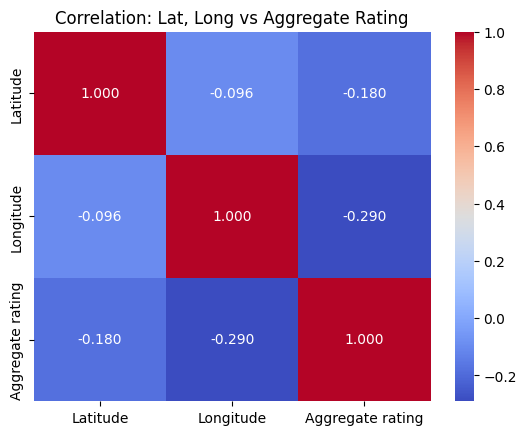

In [27]:
# Check if lat/long numerically correlates with rating
correlation = df[df['Aggregate rating'] > 0][['Latitude', 'Longitude', 'Aggregate rating']].corr()

print("=== Correlation: Location vs Rating ===")
print(correlation)

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation: Lat, Long vs Aggregate Rating')
plt.show()

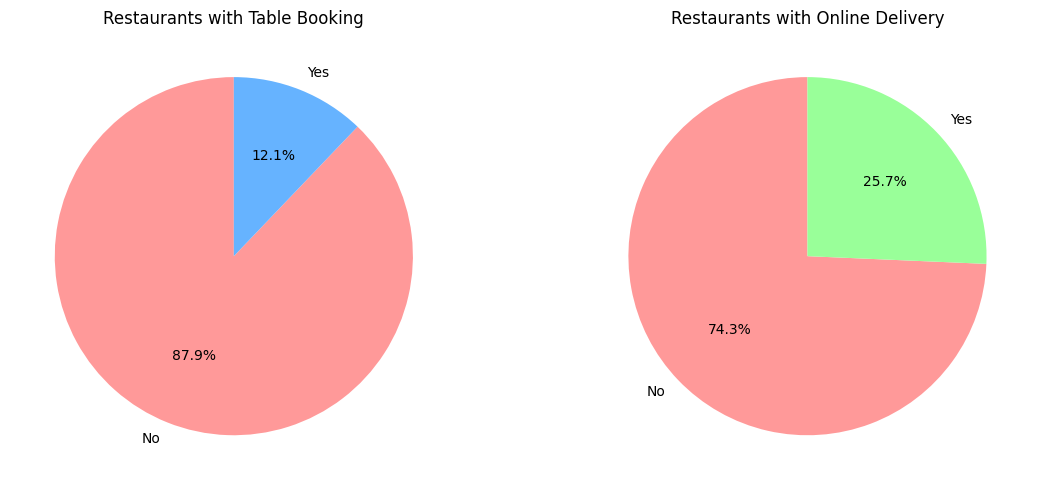

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

table_booking = df['Has Table booking'].value_counts()
online_delivery = df['Has Online delivery'].value_counts()

# Table booking pie
axes[0].pie(
    table_booking,
    labels=['No', 'Yes'],
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff'],
    startangle=90
)
axes[0].set_title('Restaurants with Table Booking')

# Online delivery pie
axes[1].pie(
    online_delivery,
    labels=['No', 'Yes'],
    autopct='%1.1f%%',
    colors=['#ff9999', '#99ff99'],
    startangle=90
)
axes[1].set_title('Restaurants with Online Delivery')

plt.tight_layout()
plt.show()

 "Only 12.1% of restaurants offer table booking, indicating it remains a feature of premium/formal dining establishments. Online delivery is more widely adopted at 25.7%, though still limited — likely reflecting the dataset's time period before the food delivery boom."

In [32]:
# Use rated restaurants only
df_rated = df[df['Aggregate rating'] > 0]

# Average rating by table booking
rating_by_booking = df_rated.groupby('Has Table booking')['Aggregate rating'].mean()
print("=== Avg Rating by Table Booking ===")
print(f"Without Table Booking: {rating_by_booking[0]:.2f}")
print(f"With Table Booking:    {rating_by_booking[1]:.2f}")

# Average rating by online delivery
rating_by_delivery = df_rated.groupby('Has Online delivery')['Aggregate rating'].mean()
print("\n=== Avg Rating by Online Delivery ===")
print(f"Without Online Delivery: {rating_by_delivery[0]:.2f}")
print(f"With Online Delivery:    {rating_by_delivery[1]:.2f}")

=== Avg Rating by Table Booking ===
Without Table Booking: 3.41
With Table Booking:    3.59

=== Avg Rating by Online Delivery ===
Without Online Delivery: 3.47
With Online Delivery:    3.38


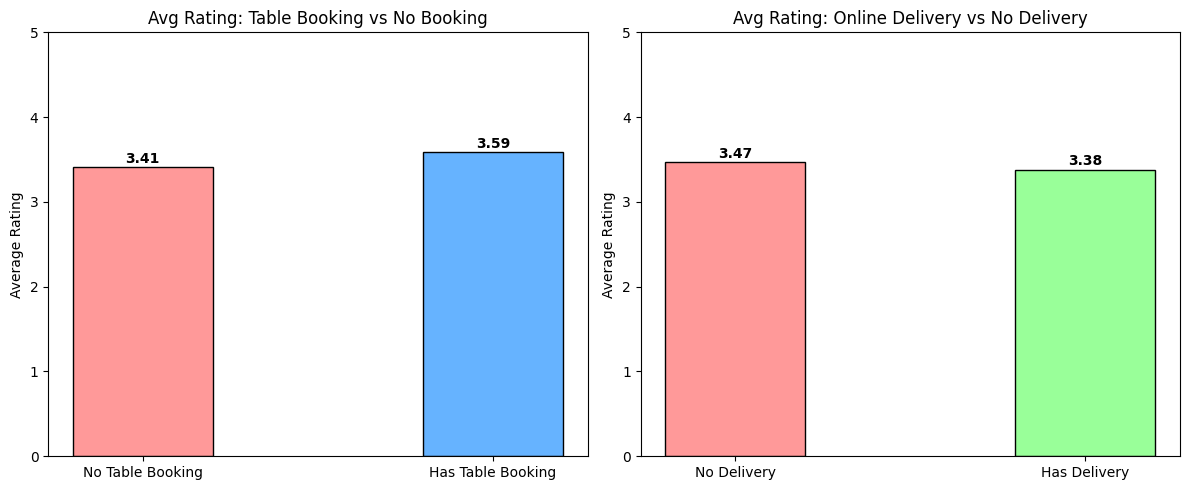

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Table booking vs rating
axes[0].bar(
    ['No Table Booking', 'Has Table Booking'],
    rating_by_booking.values,
    color=['#ff9999', '#66b3ff'],
    edgecolor='black',
    width=0.4
)
axes[0].set_title('Avg Rating: Table Booking vs No Booking')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5)
for i, v in enumerate(rating_by_booking.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Online delivery vs rating
axes[1].bar(
    ['No Delivery', 'Has Delivery'],
    rating_by_delivery.values,
    color=['#ff9999', '#99ff99'],
    edgecolor='black',
    width=0.4
)
axes[1].set_title('Avg Rating: Online Delivery vs No Delivery')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5)
for i, v in enumerate(rating_by_delivery.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

=== Online Delivery % by Price Range ===
Has Online delivery      0      1
Price range                      
1                    84.20  15.80
2                    58.69  41.31
3                    70.75  29.25
4                    90.96   9.04


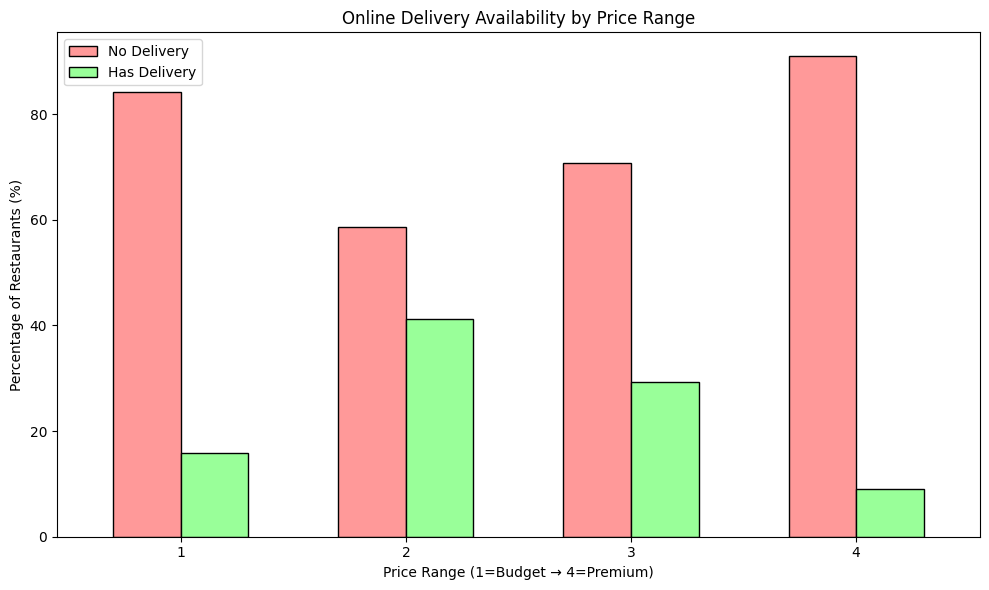

In [34]:
# Online delivery across price ranges
delivery_by_price = df.groupby('Price range')['Has Online delivery']\
                      .value_counts(normalize=True)\
                      .unstack() * 100

print("=== Online Delivery % by Price Range ===")
print(delivery_by_price.round(2))

# Plot
delivery_by_price.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#ff9999', '#99ff99'],
    edgecolor='black',
    width=0.6
)
plt.title('Online Delivery Availability by Price Range')
plt.xlabel('Price Range (1=Budget → 4=Premium)')
plt.ylabel('Percentage of Restaurants (%)')
plt.xticks(rotation=0)
plt.legend(['No Delivery', 'Has Delivery'])
plt.tight_layout()
plt.show()

=== Restaurant Count by Price Range ===
Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

Most Common Price Range: 1


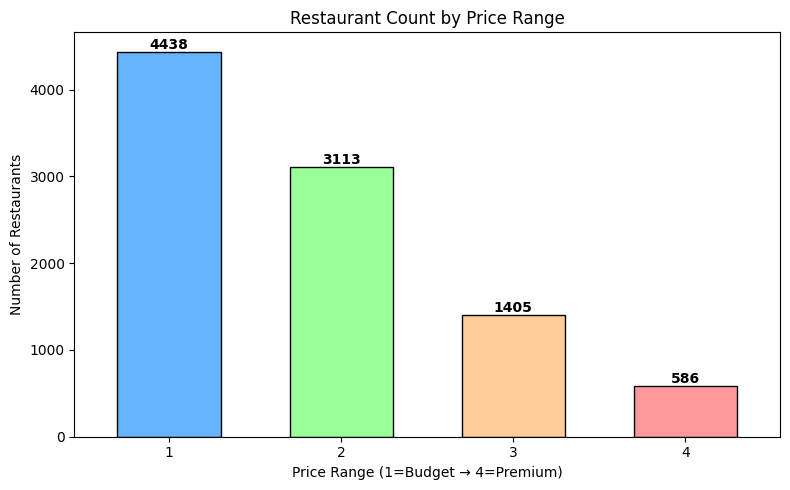

In [35]:
# Count of restaurants per price range
price_counts = df['Price range'].value_counts().sort_index()
print("=== Restaurant Count by Price Range ===")
print(price_counts)

# Most common
most_common = df['Price range'].mode()[0]
print(f"\nMost Common Price Range: {most_common}")

# Visualize
price_counts.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#66b3ff','#99ff99','#ffcc99','#ff9999'],
    edgecolor='black',
    width=0.6
)
plt.title('Restaurant Count by Price Range')
plt.xlabel('Price Range (1=Budget → 4=Premium)')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
for i, v in enumerate(price_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

"Price Range 1 (Budget) is the most common with 4,438 restaurants (46.5%), followed by Price Range 2 (32.6%). Premium restaurants (Price 4) represent only 6.1% of the dataset. This reflects a typical market structure where affordable dining dominates volume."



=== Average Rating by Price Range ===
Price range
1    3.24
2    3.38
3    3.78
4    3.89
Name: Aggregate rating, dtype: float64


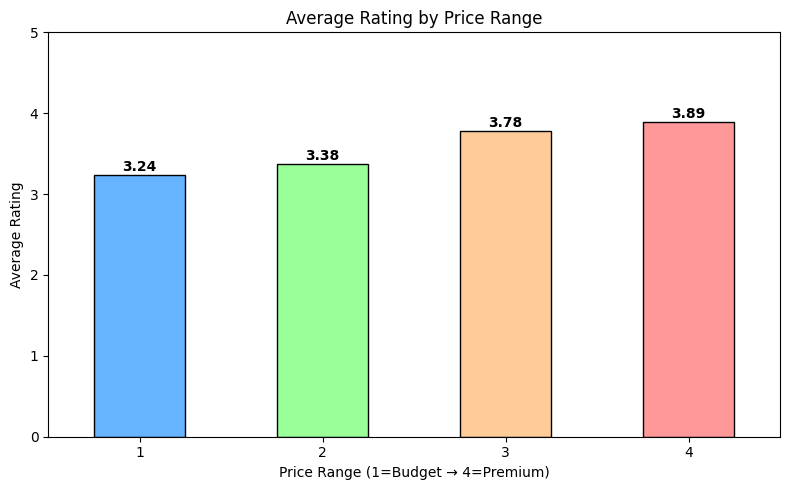

In [36]:
# Use rated restaurants only
df_rated = df[df['Aggregate rating'] > 0]

# Average rating by price range
rating_by_price = df_rated.groupby('Price range')['Aggregate rating'].mean()
print("=== Average Rating by Price Range ===")
print(rating_by_price.round(2))

# Visualize
rating_by_price.plot(
    kind='bar',
    figsize=(8, 5),
    color=['#66b3ff','#99ff99','#ffcc99','#ff9999'],
    edgecolor='black',
    width=0.5
)
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range (1=Budget → 4=Premium)')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=0)
for i, v in enumerate(rating_by_price.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

 "A consistent positive relationship exists between price range and average rating. Budget restaurants (Price 1) average 3.24 while premium restaurants (Price 4) average 3.89 — a difference of 0.65 points. The sharpest quality jump occurs between Price Range 2 and 3 (+0.40), suggesting upper-mid dining represents a significant quality threshold.

In [37]:
# Step 1 - See rating colors
print("=== Unique Rating Colors ===")
print(df['Rating color'].unique())
print()

# Step 2 - Avg rating by color
color_rating = df_rated.groupby('Rating color')['Aggregate rating']\
                       .mean().sort_values(ascending=False)
print("=== Average Rating by Color ===")
print(color_rating.round(2))

# Step 3 - Most common color per price range
color_mode_by_price = df_rated.groupby('Price range')['Rating color']\
                               .agg(lambda x: x.value_counts().index[0])
print("\n=== Most Common Color by Price Range ===")
print(color_mode_by_price)

=== Unique Rating Colors ===
['Dark Green' 'Green' 'Yellow' 'Orange' 'White' 'Red']

=== Average Rating by Color ===
Rating color
Dark Green    4.66
Green         4.17
Yellow        3.68
Orange        3.05
Red           2.30
Name: Aggregate rating, dtype: float64

=== Most Common Color by Price Range ===
Price range
1    Orange
2    Orange
3    Yellow
4    Yellow
Name: Rating color, dtype: object



=== Average Rating by Color ===
Rating color
Dark Green    4.66
Green         4.17
Yellow        3.68
Orange        3.05
Red           2.30
Name: Aggregate rating, dtype: float64


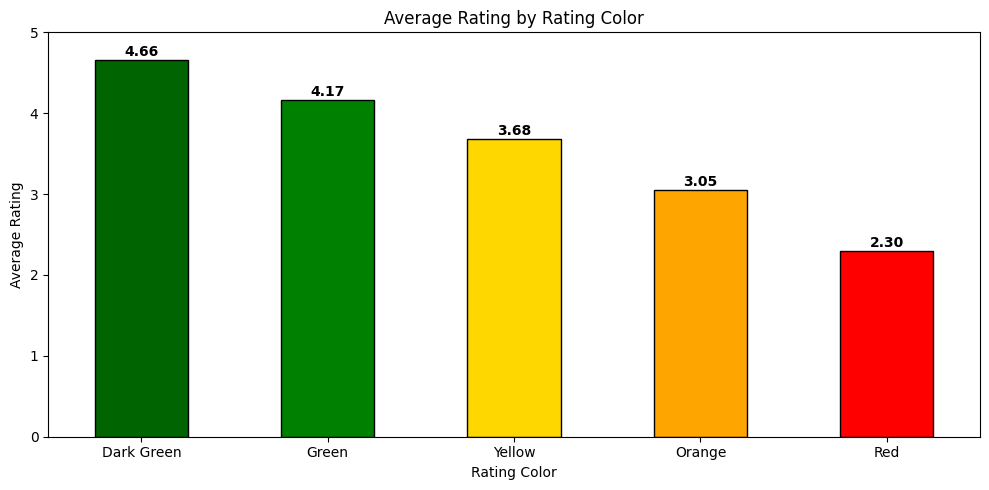

In [38]:
# Step 4 — Visualize avg rating by color
color_rating = df_rated.groupby('Rating color')['Aggregate rating'].mean().sort_values(ascending=False)
print("\n=== Average Rating by Color ===")
print(color_rating.round(2))

# Map actual colors to plot
color_map = {
    'Dark Green': 'darkgreen',
    'Green': 'green',
    'Yellow': 'gold',
    'Orange': 'orange',
    'Red': 'red',
    'White': 'lightgray'
}

colors = [color_map.get(c, 'blue') for c in color_rating.index]

color_rating.plot(
    kind='bar',
    figsize=(10, 5),
    color=colors,
    edgecolor='black',
    width=0.5
)
plt.title('Average Rating by Rating Color')
plt.xlabel('Rating Color')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=0)
for i, v in enumerate(color_rating.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Dark Green represents the highest average rating (4.66), followed by Green (4.17), Yellow (3.68), Orange (3.05), and Red (2.30). The color system perfectly reflects Zomato's rating tiers. The largest quality drop occurs between Yellow→Orange and Orange→Red, suggesting these are the most meaningful quality thresholds in the rating system.

In [39]:
# 1. Length of Restaurant Name
df['Restaurant Name Length'] = df['Restaurant Name'].str.len()

# 2. Length of Address
df['Address Length'] = df['Address'].str.len()

# 3. Length of Locality
df['Locality Length'] = df['Locality'].str.len()

# Verify
print("=== New Length Features ===")
print(df[['Restaurant Name', 'Restaurant Name Length',
          'Address', 'Address Length']].head())

print("\n=== Stats of New Features ===")
print(df[['Restaurant Name Length',
          'Address Length',
          'Locality Length']].describe().round(2))

=== New Length Features ===
          Restaurant Name  Restaurant Name Length  \
0        Le Petit Souffle                      16   
1        Izakaya Kikufuji                      16   
2  Heat - Edsa Shangri-La                      22   
3                    Ooma                       4   
4             Sambo Kojin                      11   

                                             Address  Address Length  
0  Third Floor, Century City Mall, Kalayaan Avenu...              71  
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...              67  
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...              56  
3  Third Floor, Mega Fashion Hall, SM Megamall, O...              70  
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...              64  

=== Stats of New Features ===
       Restaurant Name Length  Address Length  Locality Length
count                 9542.00         9542.00          9542.00
mean                    15.16           53.55            14.02
std    

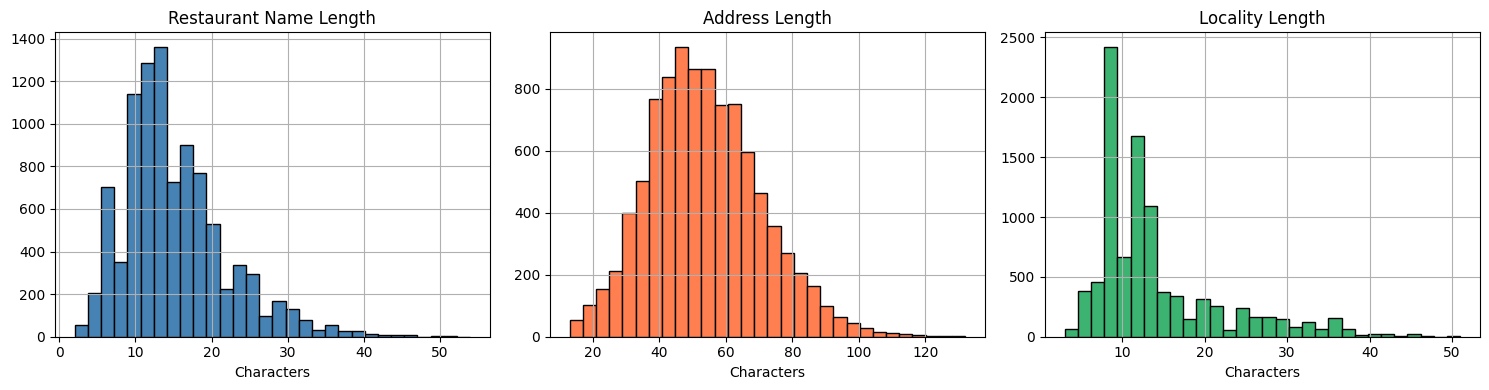

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Restaurant Name Length'].hist(bins=30, ax=axes[0],
                                   color='steelblue', edgecolor='black')
axes[0].set_title('Restaurant Name Length')
axes[0].set_xlabel('Characters')

df['Address Length'].hist(bins=30, ax=axes[1],
                           color='coral', edgecolor='black')
axes[1].set_title('Address Length')
axes[1].set_xlabel('Characters')

df['Locality Length'].hist(bins=30, ax=axes[2],
                            color='mediumseagreen', edgecolor='black')
axes[2].set_title('Locality Length')
axes[2].set_xlabel('Characters')

plt.tight_layout()
plt.show()

"Three length-based features were extracted. Restaurant names peak at 10-15 characters, addresses show a near-normal distribution centered at 45-60 characters, and locality names peak sharply at 8-10 characters. These numerical features capture textual complexity and can serve as proxy signals for restaurant type and location specificity in modeling."

=== Sample of All New Features ===
   Restaurant Name Length  Address Length  Locality Length  \
0                      16              71               41   
1                      16              67               42   
2                      22              56               42   
3                       4              70               38   
4                      11              64               38   
5                      12              71               38   
6                      10              83               47   
7                       7              81               47   
8                      40              69               43   
9                       8              67                9   

   Rating Text Encoded  Rating Color Encoded  Cuisine Count  
0                    5                     5              3  
1                    5                     5              1  
2                    4                     4              4  
3                    5            

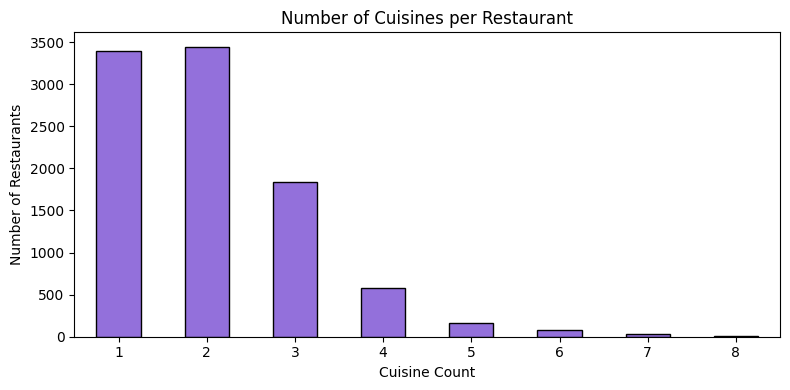

In [41]:
# Run all encoding + cuisine count + final verify
# Part 2 — Encoding
rating_mapping = {
    'Not rated':0, 'Poor':1, 'Average':2,
    'Good':3, 'Very Good':4, 'Excellent':5
}
df['Rating Text Encoded'] = df['Rating text'].map(rating_mapping)

color_mapping = {
    'White':0, 'Red':1, 'Orange':2,
    'Yellow':3, 'Green':4, 'Dark Green':5
}
df['Rating Color Encoded'] = df['Rating color'].map(color_mapping)

df['Cuisine Count'] = df['Cuisines'].str.split(',').apply(len)

# Part 3 — Verify everything
new_features = ['Restaurant Name Length', 'Address Length',
                'Locality Length', 'Rating Text Encoded',
                'Rating Color Encoded', 'Cuisine Count']

print("=== Sample of All New Features ===")
print(df[new_features].head(10))
print(f"\nFinal Dataset Shape: {df.shape}")

# Cuisine count chart
df['Cuisine Count'].value_counts().sort_index().plot(
    kind='bar', figsize=(8,4),
    color='mediumpurple', edgecolor='black'
)
plt.title('Number of Cuisines per Restaurant')
plt.xlabel('Cuisine Count')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()